## Imports

In [1]:
from collections.abc import Iterable
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

/scratch/s5033373/repos/data_privacy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utils

In [2]:
def sequence_losses(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    texts: Iterable[str],
    batch_size: int = 8,
    max_length: int = 2048,
    device: str | torch.device | None = None,
) -> list[float]:
    """
    takes in model, tokenizer and text,
    returns mean next token cross-entropy for each text
    """

    texts = [str(text) for text in texts]
    if not texts:
        return []

    device = torch.device(device or next(model.parameters()).device)
    model.eval()

    # bucket to reduce padding
    tokenized_lengths = tokenizer(
        texts,
        add_special_tokens=True,
        truncation=True,
        max_length=max_length,
        padding=False,
    )["input_ids"]
    sorted_indices = sorted(
        range(len(texts)),
        key=lambda index: len(tokenized_lengths[index]),
    )
    sorted_texts = [texts[index] for index in sorted_indices]
    sorted_losses: list[float] = []

    for start in tqdm(range(0, len(sorted_texts), batch_size)):
        batch = sorted_texts[start : start + batch_size]
        encoded = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        input_ids = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        with torch.inference_mode():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

        token_labels = input_ids[:, 1:]
        valid_tokens = attention_mask[:, 1:].bool()
        token_losses = torch.nn.functional.cross_entropy(
            logits[:, :-1].float().transpose(1, 2),
            token_labels,
            reduction="none",
        )
        token_losses = token_losses.masked_fill(~valid_tokens, 0.0)
        token_counts = valid_tokens.sum(dim=1)
        sorted_losses.extend((token_losses.sum(dim=1) / token_counts).cpu().tolist())

    losses = [0.0] * len(texts)
    for sorted_position, original_index in enumerate(sorted_indices):
        losses[original_index] = sorted_losses[sorted_position]
    return losses



def load_model(model_name: str, device: str) -> tuple[AutoModelForCausalLM, AutoTokenizer, torch.device]:

    resolved_device = torch.device(device)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.bfloat16 if resolved_device.type == "cuda" else torch.float32
    ).to(resolved_device)
    model.config.pad_token_id = tokenizer.pad_token_id
    return model, tokenizer, resolved_device

## LOSS attack

In [3]:

def loss_attack(member_losses: list[float], non_member_losses: list[float]) -> dict[str, float]:
    # TODO: currently usses mean member loss as a threshold which leaks information
    # should have a preset threshold/threshold thru val set but 
    # since the attack doesn't work anyway i haven't changed it yet

    losses = member_losses + non_member_losses
    labels = [1] * len(member_losses) + [0] * len(non_member_losses)
    threshold = float(sum(member_losses) / len(member_losses))
    scores = [-loss for loss in losses]
    predictions = [int(loss <= threshold) for loss in losses]

    return {
        "threshold_mean_member_loss": threshold,
        "roc_auc": float(roc_auc_score(labels, scores)),
        "accuracy": float(accuracy_score(labels, predictions)),
        "member_mean_loss": float(sum(member_losses) / len(member_losses)),
        "non_member_mean_loss": float(sum(non_member_losses) / len(non_member_losses)),
    }

## Configuration

In [4]:
# Configuration parameters
MODEL_NAME = "EleutherAI/pythia-1b"
MEMBERS_PATH = Path("../dataset/members.parquet")
NON_MEMBERS_PATH = Path("../dataset/non_members.parquet")
BATCH_SIZE = 4
MAX_LENGTH = 2048
LIMIT = None
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# load parquet datasets
member_texts = pd.read_parquet(MEMBERS_PATH)["text"].dropna().astype(str).tolist()
non_member_texts = pd.read_parquet(NON_MEMBERS_PATH)["text"].dropna().astype(str).tolist()

if LIMIT is not None:
    member_texts = member_texts[:LIMIT]
    non_member_texts = non_member_texts[:LIMIT]

print(f"Loaded {len(member_texts)} member samples and {len(non_member_texts)} non-member samples.")

Loaded 5000 member samples and 5000 non-member samples.


## Load model and tokenizer

In [5]:
model, tokenizer, device = load_model(MODEL_NAME, DEVICE)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 196/196 [00:01<00:00, 145.24it/s]


## Running LOSS attack

Sequence losses for members:


100%|██████████| 1250/1250 [02:06<00:00,  9.91it/s]


Sequence losses for non-members:


100%|██████████| 1250/1250 [02:00<00:00, 10.34it/s]



Model: EleutherAI/pythia-1b
Members: 5000 | Non-members: 5000

threshold_mean_member_loss: 2.274377
roc_auc: 0.498808
accuracy: 0.497700
member_mean_loss: 2.274377
non_member_mean_loss: 2.272245


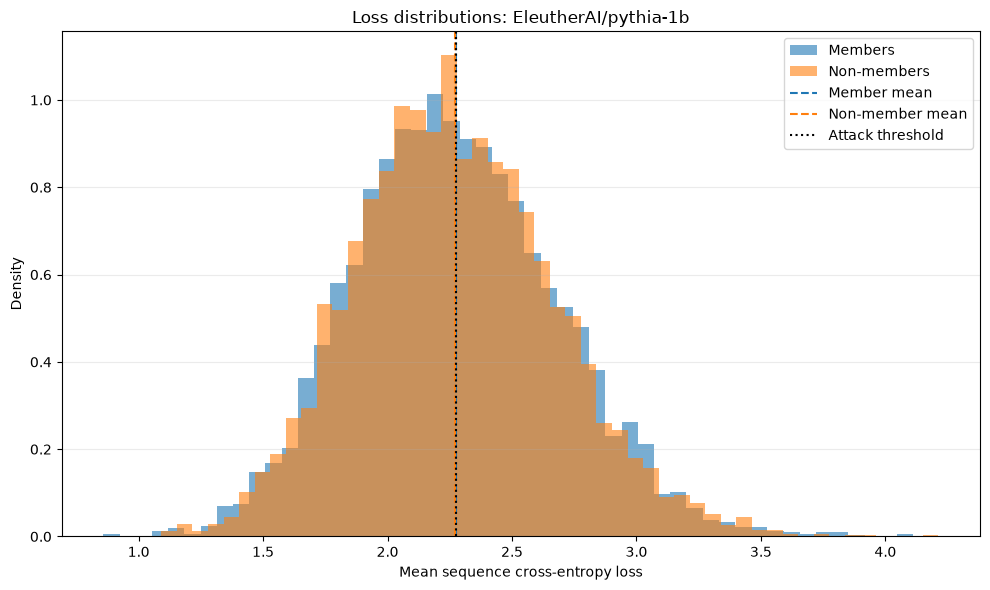

In [6]:
print("Sequence losses for members:")
member_losses = sequence_losses(model, tokenizer, member_texts, BATCH_SIZE, MAX_LENGTH, device)

print("Sequence losses for non-members:")
non_member_losses = sequence_losses(model, tokenizer, non_member_texts, BATCH_SIZE, MAX_LENGTH, device)

# run attack
print(f"\nModel: {MODEL_NAME}")
print(f"Members: {len(member_losses)} | Non-members: {len(non_member_losses)}\n")

results = loss_attack(member_losses, non_member_losses)
for name, value in results.items():
    print(f"{name}: {value:.6f}")

# Distribution plot
bins = 50
plt.figure(figsize=(10, 6))
plt.hist(member_losses, bins=bins, density=True, alpha=0.6, label="Members")
plt.hist(non_member_losses, bins=bins, density=True, alpha=0.6, label="Non-members")
plt.axvline(results["member_mean_loss"], color="C0", linestyle="--", label="Member mean")
plt.axvline(results["non_member_mean_loss"], color="C1", linestyle="--", label="Non-member mean")
plt.axvline(results["threshold_mean_member_loss"], color="black", linestyle=":", label="Attack threshold")
plt.xlabel("Mean sequence cross-entropy loss")
plt.ylabel("Density")
plt.title(f"Loss distributions: {MODEL_NAME}")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Reference attack

## Implementation

In [7]:
def reference_attack(member_losses_target: list[float], non_member_losses_target: list[float], member_losses_ref: list[float], non_member_losses_ref: list[float]) -> dict[str, float]:
    """
    Score = loss_ref - loss_target. If the score is high that means that the reference model was surprised by the example, 
    meaning that the example is more likely to be a member of the training set of the target model. Based on the Caralini et al. 2021 paper
    """
    
    # code reference used: https://stackoverflow.com/questions/534855/subtracting-2-lists-in-python
    member_scores = [ref - target for ref, target in zip(member_losses_ref, member_losses_target)]
    non_member_scores = [ref - target for ref, target in zip(non_member_losses_ref, non_member_losses_target)]
    
    scores = member_scores + non_member_scores
    labels = [1] * len(member_scores) + [0] * len(non_member_scores)
    threshold = float(sum(member_scores) / len(member_scores))
    predictions = [int(s >= threshold) for s in scores]

    return {
        "threshold_mean_member_loss": threshold,
        "roc_auc": float(roc_auc_score(labels, scores)),
        "accuracy": float(accuracy_score(labels, predictions)),
        "member_mean_score": float(sum(member_scores) / len(member_scores)),
        "non_member_mean_score": float(sum(non_member_scores) / len(non_member_scores)),
        "member_scores": member_scores,
        "non_member_scores": non_member_scores
    }

# Loading reference model GPT2

In [8]:
REF_MODEL = "openai-community/gpt2"
ref_model, ref_tokenizer, ref_device = load_model(REF_MODEL, DEVICE)

# using the loss code from above to compute the reference model losses for members and non-members
print("Reference model losses for members:")
member_losses_ref = sequence_losses(ref_model, ref_tokenizer, member_texts, BATCH_SIZE, MAX_LENGTH, ref_device)

print("Reference model losses for non-members:")
non_member_losses_ref = sequence_losses(ref_model, ref_tokenizer, non_member_texts, BATCH_SIZE, MAX_LENGTH, ref_device)

# run reference attack
print(f"\nReference Model: {REF_MODEL}")
ref_results = reference_attack(member_losses, non_member_losses, member_losses_ref, non_member_losses_ref)
for name, value in ref_results.items():
    if name not in ["member_scores", "non_member_scores"]:
        print(f"{name}: {value:.6f}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 530.02it/s]


Reference model losses for members:


100%|██████████| 1250/1250 [01:51<00:00, 11.25it/s]


Reference model losses for non-members:


100%|██████████| 1250/1250 [01:51<00:00, 11.22it/s]



Reference Model: openai-community/gpt2
threshold_mean_member_loss: 0.891856
roc_auc: 0.507351
accuracy: 0.506800
member_mean_score: 0.891856
non_member_mean_score: 0.884743


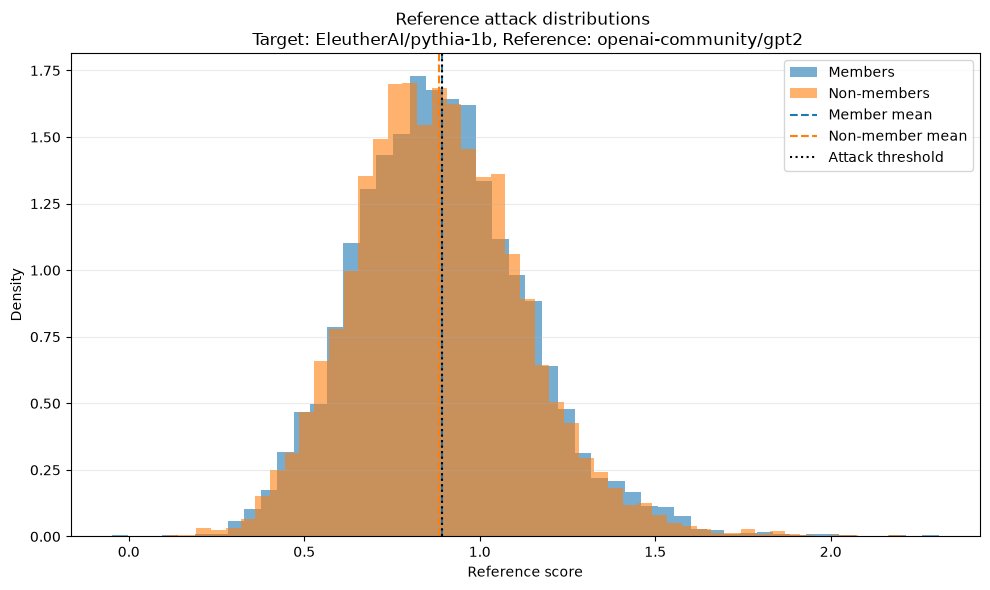

In [26]:
# Distribution plot for the reference attack
bins = 50
plt.figure(figsize=(10, 6))
plt.hist(ref_results["member_scores"], bins=bins, density=True, alpha=0.6, label="Members")
plt.hist(ref_results["non_member_scores"], bins=bins, density=True, alpha=0.6, label="Non-members")
plt.axvline(ref_results["member_mean_score"], color="C0", linestyle="--", label="Member mean")
plt.axvline(ref_results["non_member_mean_score"], color="C1", linestyle="--", label="Non-member mean")
plt.axvline(ref_results["threshold_mean_member_loss"], color="black", linestyle=":", label="Attack threshold")
plt.xlabel("Reference score")
plt.ylabel("Density")
plt.title(f"Reference attack distributions \n Target: {MODEL_NAME}, Reference: {REF_MODEL}")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Store the losses for future experiments

In [13]:
from pathlib import Path

LOSSES_PATH = Path("../dataset/losses.parquet")

In [20]:
member_losses_df = pd.DataFrame({
    "target_loss": member_losses,
    "ref_loss": member_losses_ref,
    "split": "member"
})

non_member_losses_df = pd.DataFrame({
    "target_loss": non_member_losses,
    "ref_loss": non_member_losses_ref,
    "split": "non_member"
})

In [21]:
print(member_losses_df.shape)
display(member_losses_df.head(5))

print(non_member_losses_df.shape)
display(non_member_losses_df.head(5))


(5000, 3)


,target_loss,ref_loss,split
0,3.013538,4.048715,member
1,2.449759,3.374582,member
2,1.802487,2.907557,member
3,2.586885,3.527138,member
4,2.158955,3.037329,member


(5000, 3)


,target_loss,ref_loss,split
0,1.736943,3.026514,non_member
1,2.487920,3.025043,non_member
2,1.897352,2.841147,non_member
3,2.216264,2.794031,non_member
4,2.329805,3.544364,non_member


In [22]:
pd.concat([member_losses_df, non_member_losses_df], ignore_index=True).to_parquet(LOSSES_PATH, index=False)

- loading the saved file

In [25]:
if LOSSES_PATH.exists():
    losses_df = pd.read_parquet(LOSSES_PATH)

print(losses_df.shape)
print(losses_df['split'].value_counts())
display(losses_df.head(5))

(10000, 3)
split
member        5000
non_member    5000
Name: count, dtype: int64


,target_loss,ref_loss,split
0,3.013538,4.048715,member
1,2.449759,3.374582,member
2,1.802487,2.907557,member
3,2.586885,3.527138,member
4,2.158955,3.037329,member
